In [2]:
from datasets.offline_rl.maze2d import Maze2dOfflineRLDataset

In [3]:
dataset_url="http://rail.eecs.berkeley.edu/datasets/offline_rl/maze2d/maze2d-medium-sparse-v1.hdf5"

In [6]:
import os
import urllib

def download_dataset_from_url(save_dir, dataset_url):
    _, dataset_name = os.path.split(dataset_url)
    dataset_filepath = os.path.join(save_dir, dataset_name)
    if not os.path.exists(dataset_filepath):
        print("Downloading dataset:", dataset_url, "to", dataset_filepath)
        urllib.request.urlretrieve(dataset_url, dataset_filepath)
    if not os.path.exists(dataset_filepath):
        raise IOError("Failed to download dataset from %s" % dataset_url)
    return dataset_filepath


h5path = download_dataset_from_url("./data/maze2d", dataset_url)
      

In [7]:
h5path

'./data/maze2d/maze2d-medium-sparse-v1.hdf5'

In [9]:
import h5py

def get_keys(h5file):
    keys = []

    def visitor(name, item):
        if isinstance(item, h5py.Dataset):
            keys.append(name)

    h5file.visititems(visitor)
    return keys

data_dict = {}
with h5py.File(h5path, "r") as dataset_file:
    for k in get_keys(dataset_file):
        print("key", k)
        try:  # first try loading as an array
            data_dict[k] = dataset_file[k][:]
        except ValueError as e:  # try loading as a scalar
            data_dict[k] = dataset_file[k][()]

N_samples = data_dict["observations"].shape[0]
print("N_samples", N_samples)

if data_dict["rewards"].shape == (N_samples, 1):
    data_dict["rewards"] = data_dict["rewards"][:, 0]
    print("has rewards")

if data_dict["terminals"].shape == (N_samples, 1):
    data_dict["terminals"] = data_dict["terminals"][:, 0]
    print("has terminals")

key actions
key infos/goal
key infos/qpos
key infos/qvel
key observations
key rewards
key terminals
key timeouts
N_samples 2000000


In [18]:
data_dict["observations"][0]

array([1.0016748 , 6.088227  , 0.05658022, 0.0398099 ], dtype=float32)

In [19]:
import gym
import d4rl
env = gym.make('maze2d-medium-v1')
print(env.str_maze_spec)

No module named 'mjrl'
No module named 'flow'
/users/dhoffmann/miniconda3/envs/diffusion-forcing/lib/python3.10/site-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: Failed to open display localhost:10.0'
  warnings.warn(message, GLFWError)
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


########\#OO##OO#\#OO#OOO#\##OOO###\#OO#OOO#\#O#OO#O#\#OOO#OG#\########


In [33]:
from maze_dataset import MazeDataset, MazeDatasetConfig
from maze_dataset.generation import LatticeMazeGenerators
cfg: MazeDatasetConfig = MazeDatasetConfig(
	name="test", # name is only for you to keep track of things
	grid_n=5, # number of rows/columns in the lattice
	n_mazes=4, # number of mazes to generate
	maze_ctor=LatticeMazeGenerators.gen_dfs, # algorithm to generate the maze
    # maze_ctor_kwargs=dict(do_forks=False, accessible_cells=None), # additional parameters to pass to the maze generation algorithm
)

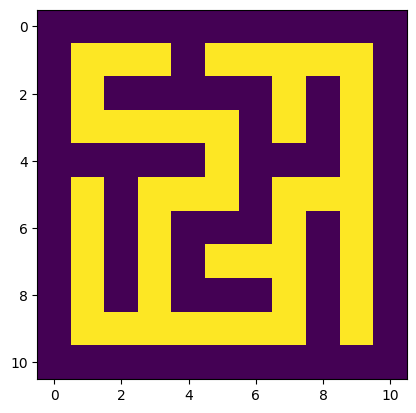

In [ ]:
import matplotlib.pyplot as plt
dataset: MazeDataset = MazeDataset.from_config(cfg)
m = dataset[2]
plt.imshow(m.) 
#0 maze without true path

In [52]:
m.as_pixels()[:,:,0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0, 255, 255,   0, 255, 255, 255, 255, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   0, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   0, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0],
       [  0, 255,   0,   0,   0,   0,   0, 255, 255, 255,   0],
       [  0, 255,   0,   0,   0,   0,   0, 255,   0, 255,   0],
       [  0, 255,   0,   0,   0, 255, 255, 255,   0, 255,   0],
       [  0, 255,   0,   0,   0,   0,   0,   0,   0, 255,   0],
       [  0, 255, 255,   0,   0,   0,   0,   0,   0, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]],
      dtype=uint8)

In [44]:
m.solution

array([[0, 0],
       [1, 0],
       [1, 1],
       [1, 2],
       [2, 2],
       [2, 1],
       [3, 1],
       [4, 1],
       [4, 2],
       [4, 3],
       [3, 3]])

In [85]:
import torch
import numpy as np
from maze_dataset import MazeDataset, MazeDatasetConfig
from torch.utils.data import Dataset

def generate_and_save(path="maze_data.npz", n_mazes=100, grid_size=8):
    cfg = MazeDatasetConfig(name="train", grid_n=grid_size, n_mazes=n_mazes)
    base_ds = MazeDataset.from_config(cfg)
    
    obs, acts, rews = [], [], []
    
    for maze in base_ds:
        grid = maze.as_pixels(False, False)[:,:,2]
        path_pixels = [(r * 2 + 1, c * 2 + 1) for r, c in maze.solution]
        goal = path_pixels[-1]
        
        for i in range(len(path_pixels)):
            curr = path_pixels[i]
            
            if i < len(path_pixels) - 1:
                nxt = path_pixels[i+1]
                if nxt[0] < curr[0]: a = 0
                elif nxt[0] > curr[0]: a = 1
                elif nxt[1] < curr[1]: a = 2
                else: a = 3
                r = 0.0
            else:
                a = 0
                r = 1.0
                
            o = np.zeros((3, grid.shape[0], grid.shape[1]), dtype=np.float32)
            o[0] = grid
            o[1, curr[0], curr[1]] = 1.0
            o[2, goal[0], goal[1]] = 1.0
            
            obs.append(o)
            acts.append(a)
            rews.append(r)

    np.savez(
        path, 
        observations=np.stack(obs), 
        actions=np.array(acts), 
        rewards=np.array(rews)
    )

class OfflineMazeDataset(Dataset):
    def __init__(self, npz_path, n_frames):
        self.dataset = np.load(npz_path)
        self.n_frames = n_frames

    def __len__(self):
        return len(self.dataset["rewards"]) - self.n_frames + 1

    def __getitem__(self, idx):
        observation = torch.from_numpy(self.dataset["observations"][idx : idx + self.n_frames]).float()
        action = torch.from_numpy(self.dataset["actions"][idx : idx + self.n_frames]).float()
        reward = torch.from_numpy(self.dataset["rewards"][idx : idx + self.n_frames]).float()

        done = np.zeros(self.n_frames, dtype=bool)
        done[-1] = True
        nonterminal = torch.from_numpy(~done)

        return observation, action, reward, nonterminal

generate_and_save("maze_data.npz")
dataset = OfflineMazeDataset("maze_data.npz", n_frames=4)

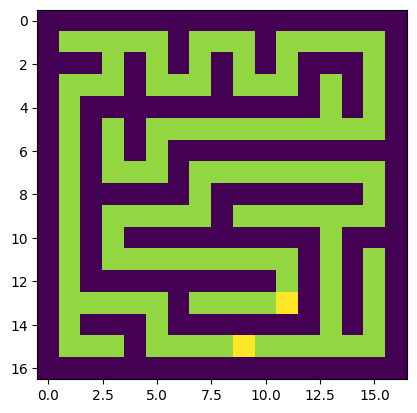

In [ ]:
plt.imshow(dataset[0][0][0][0] + dataset[0][0][0][1]*50 + dataset[0][0][0][2]*50)

In [102]:
dataset[0][1]

tensor([0., 2., 2., 2.])